In [20]:
import matplotlib as mpl
import seaborn as sns
import importlib

# Seaborn theme
sns.set_theme(
    style="ticks",        # "white", "whitegrid", "ticks", "darkgrid"
    context="paper",       # notebook, paper, talk, poster
    palette="deep"
)

# Your publication formatting
mpl.rcParams.update({

    # Fonts
    "font.family": "Arial",
    "font.size": 14,

    # Figure titles
    "figure.titlesize": 34,
    "figure.titleweight": "bold",

    # Axes titles/labels
    "axes.titlesize": 14,
    "axes.labelsize": 14,

    # Tick labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 12,

    # Lines & markers
    "lines.linewidth": 3,
    "lines.markersize": 8,

    # Axes
    "axes.linewidth": 2,

    # Ticks
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,

    # Grid
    "grid.linewidth": 1,
    "grid.alpha": 0.3,

    # Export
    "figure.dpi": 150,
    "savefig.dpi": 600,

    # Editable vector graphics
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# Manuscript Figure 3 — Curvature and receptor density act synergistically

Analyzes the 5×5 cylindrical-sheet curvature/receptor-density factorial experiment and explicitly estimates the curvature × density interaction.


In [21]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "analysis_tools":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis_tools.manuscript_escape_analysis import (
    classical_occupancy, condition_statistics, discover_runs,
    load_receptor_summaries, occupancy_from_bound_time,
    replicate_survival_curves, save_figure, summarize_replicates,
)

SAVE_FIGURES = False
FIGURE_ROOT = PROJECT_ROOT / "analysis_tools" / "manuscript_panels"


In [22]:
DATA_ROOT = "/Users/rynon/Library/CloudStorage/OneDrive-NorthwesternUniversity/PhD/Data/Agent-based simulations/261005_manuscript_fig3_curvature_density_factorial"
run_index = discover_runs(DATA_ROOT)
replicates = summarize_replicates(run_index)
replicates["curvature_nm_inv"] = replicates["curvature_m_inv"] * 1e-9
replicates["density_1e16_m2"] = replicates["receptor_density_m2"] / 1e16
# display(replicates.groupby(["curvature_nm_inv", "density_1e16_m2"]).size().unstack())


## 1. Quality control


In [23]:
# display(replicates.groupby(["curvature_nm_inv", "density_1e16_m2"])[["n_receptors", "n_trajectories", "censoring_fraction"]].agg(["mean", "min", "max"]))


## 2. Figure 3A–C: factorial heatmaps


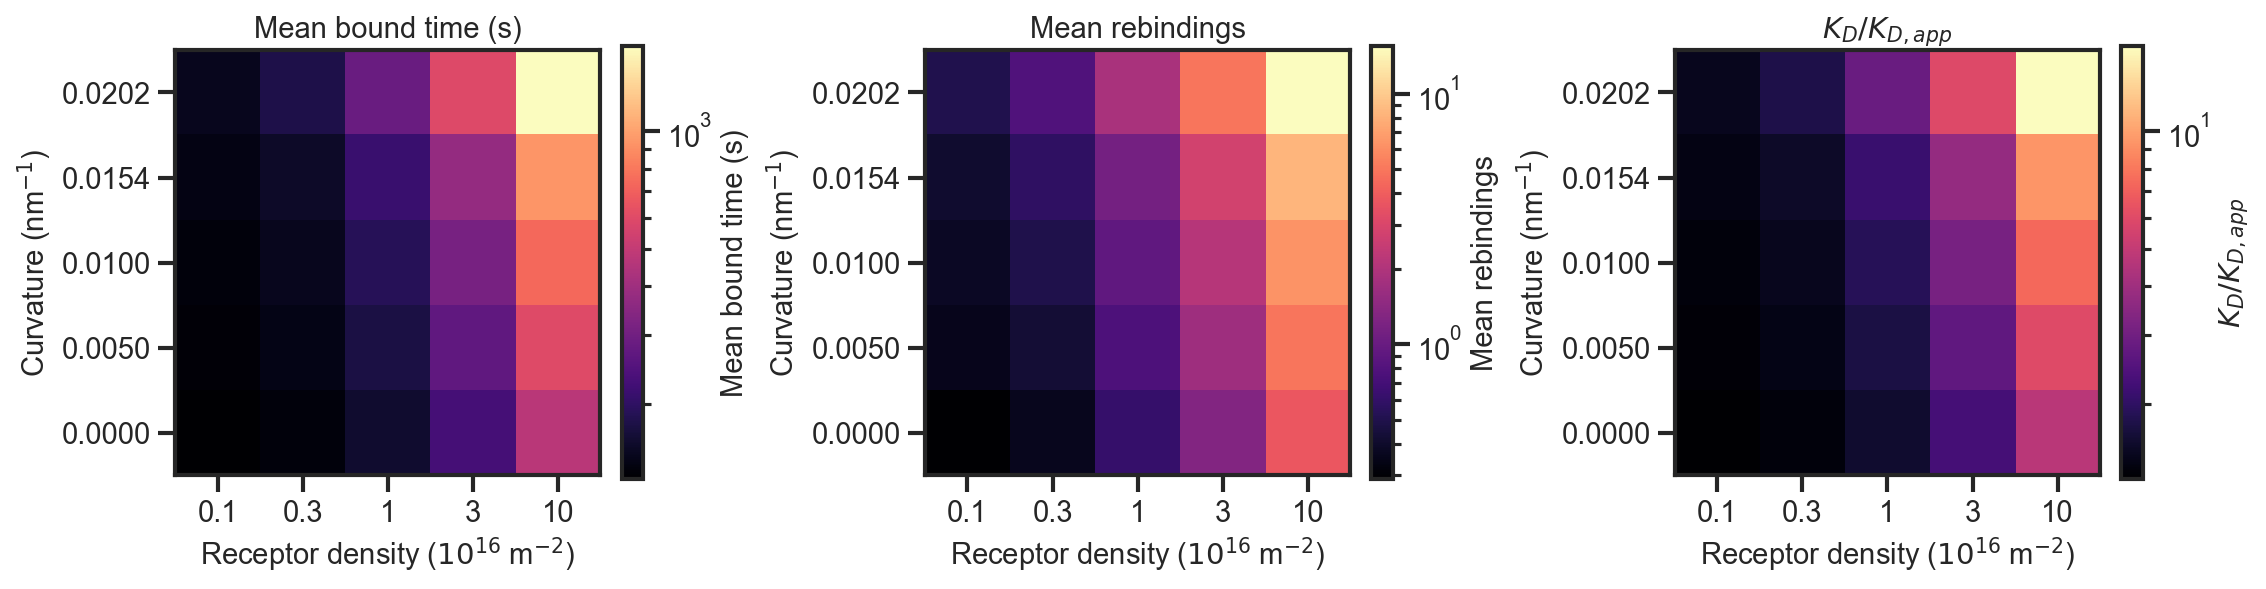

In [ ]:
metrics = [("mean_bound_time_s", "Mean bound time (s)"), ("mean_rebindings", "Mean rebindings"), ("affinity_shift_fold", r"$K_D/K_{D,app}$")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, (metric, title) in zip(axes, metrics):
    matrix = replicates.pivot_table(index="curvature_nm_inv", columns="density_1e16_m2", values=metric, aggfunc="mean").sort_index().sort_index(axis=1)
    values = matrix.to_numpy(float)
    positive_values = values[np.isfinite(values) & (values > 0)]
    if positive_values.size == 0:
        raise ValueError(f"{metric} has no positive values and cannot use a log color scale.")
    vmin, vmax = positive_values.min(), positive_values.max()
    if np.isclose(vmin, vmax):
        vmax = vmin * (1 + 1e-6)
    log_values = np.ma.masked_less_equal(values, 0)
    cmap = mpl.colormaps["magma"].copy()
    cmap.set_bad("0.9")
    image = ax.imshow(log_values, origin="lower", aspect="equal", cmap=cmap, norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax))
    ax.set_xticks(range(matrix.shape[1]), [f"{x:g}" for x in matrix.columns])
    ax.set_yticks(range(matrix.shape[0]), [f"{x:.4f}" for x in matrix.index])
    ax.set(xlabel=r"Receptor density ($10^{16}$ m$^{-2}$)", ylabel=r"Curvature (nm$^{-1}$)", title=title)
    colorbar = fig.colorbar(image, ax=ax, shrink=.85)
    colorbar.set_label(title, )
if SAVE_FIGURES: save_figure(fig, FIGURE_ROOT, "figure3_ABC_factorial_heatmaps")
plt.show()

## 3. Figure 3D: curvature response at each density


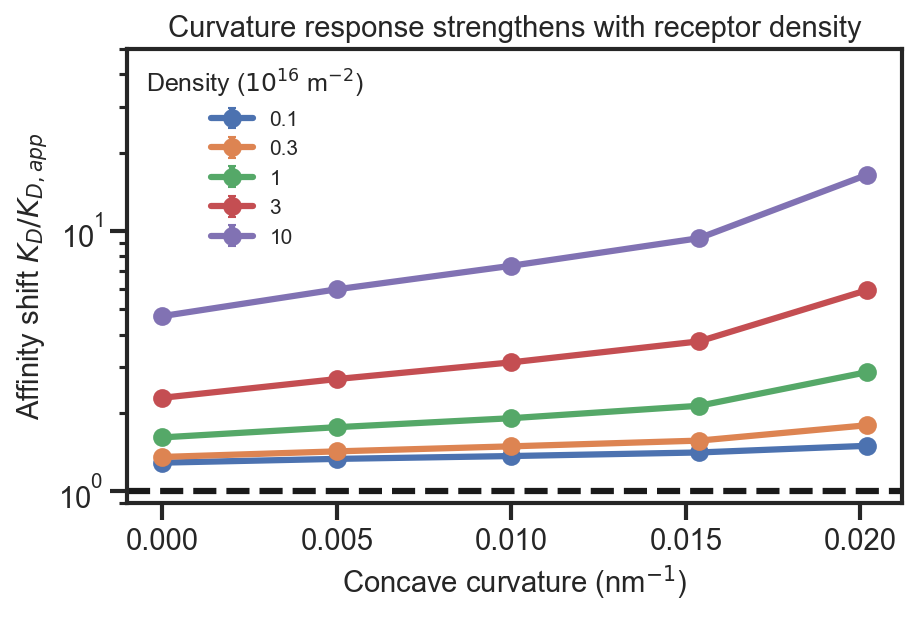

In [47]:
stats = condition_statistics(replicates, ["curvature_nm_inv", "density_1e16_m2"], ["affinity_shift_fold", "mean_bound_time_s", "mean_rebindings"])
fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)
for density, frame in stats.groupby("density_1e16_m2"):
    frame=frame.sort_values("curvature_nm_inv")
    ax.errorbar(frame.curvature_nm_inv, frame.affinity_shift_fold_mean, yerr=frame.affinity_shift_fold_sem, marker="o", capsize=2, label=f"{density:g}")
ax.axhline(1,color="k",ls="--")
ax.set(xlabel=r"Concave curvature (nm$^{-1}$)", ylabel=r"Affinity shift $K_D/K_{D,app}$", yscale="log", title="Curvature response strengthens with receptor density")
ax.legend(title=r"Density ($10^{16}$ m$^{-2}$)", loc="upper left")
ax.set_ylim(bottom=0.9, top=50)
if SAVE_FIGURES: save_figure(fig, FIGURE_ROOT, "figure3_D_synergy_lines")
plt.show()


## 4. Interaction model

The response and predictors are log/standardized so the interaction coefficient tests whether the curvature response depends on receptor density.


In [48]:
model_data = replicates.replace([np.inf,-np.inf],np.nan).dropna(subset=["affinity_shift_fold", "curvature_nm_inv", "receptor_density_m2"]).copy()
model_data["response"] = np.log(model_data.affinity_shift_fold)
curvature_center = model_data.curvature_nm_inv.mean()
curvature_scale = model_data.curvature_nm_inv.std()
log_density = np.log10(model_data.receptor_density_m2)
log_density_center = log_density.mean()
log_density_scale = log_density.std()
model_data["curvature_z"] = (model_data.curvature_nm_inv-curvature_center)/curvature_scale
model_data["log_density_z"] = (log_density-log_density_center)/log_density_scale
X = np.column_stack([np.ones(len(model_data)), model_data.curvature_z, model_data.log_density_z, model_data.curvature_z*model_data.log_density_z])
names = ["intercept", "curvature", "log_density", "curvature_x_log_density"]
beta, *_ = np.linalg.lstsq(X, model_data.response, rcond=None)
residual = model_data.response.to_numpy()-X@beta
covariance = np.linalg.inv(X.T@X)*(residual@residual)/(len(X)-X.shape[1])
interaction_table = pd.DataFrame({"term":names,"coefficient":beta,"standard_error":np.sqrt(np.diag(covariance))})
interaction_table["t_value"] = interaction_table.coefficient/interaction_table.standard_error
display(interaction_table)


,term,coefficient,standard_error,t_value
0,intercept,0.944734,0.015601,60.554541
1,curvature,0.213657,0.015641,13.660465
2,log_density,0.612059,0.015641,39.132906
3,curvature_x_log_density,0.136065,0.015680,8.677744


## 5. Interaction-model visualization

Lines show the fitted curvature response at each receptor density. Shading is the model-based 95% confidence interval; points and error bars are the observed replicate mean ± SEM.


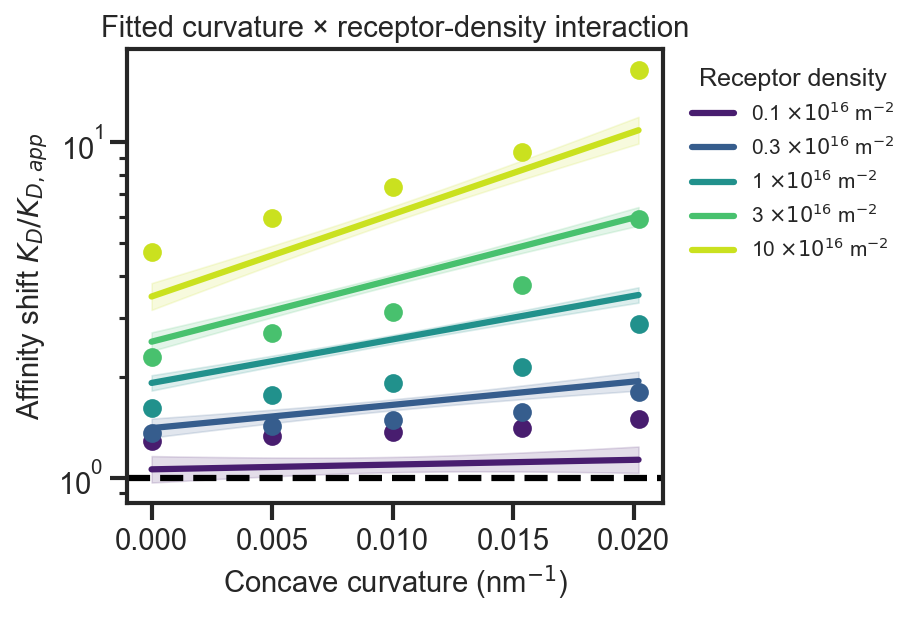

In [50]:
curvature_grid = np.linspace(model_data.curvature_nm_inv.min(), model_data.curvature_nm_inv.max(), 200)
density_values = np.sort(model_data.receptor_density_m2.unique())
density_colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(density_values)))
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
for color, density in zip(density_colors, density_values):
    curvature_z = (curvature_grid-curvature_center)/curvature_scale
    density_z = (np.log10(density)-log_density_center)/log_density_scale
    prediction_matrix = np.column_stack([
        np.ones_like(curvature_z), curvature_z,
        np.full_like(curvature_z, density_z), curvature_z*density_z,
    ])
    predicted_log = prediction_matrix @ beta
    predicted_se = np.sqrt(np.einsum("ij,jk,ik->i", prediction_matrix, covariance, prediction_matrix))
    label = rf"{density/1e16:g} $\times 10^{{16}}$ m$^{{-2}}$"
    ax.plot(curvature_grid, np.exp(predicted_log), color=color, label=label)
    ax.fill_between(curvature_grid, np.exp(predicted_log-1.96*predicted_se), np.exp(predicted_log+1.96*predicted_se), color=color, alpha=0.15)
    observed = stats.loc[np.isclose(stats.density_1e16_m2, density/1e16)].sort_values("curvature_nm_inv")
    ax.errorbar(observed.curvature_nm_inv, observed.affinity_shift_fold_mean, yerr=observed.affinity_shift_fold_sem, color=color, marker="o", linestyle="none", capsize=3)
ax.axhline(1, color="black", linestyle="--")
ax.set(xlabel=r"Concave curvature (nm$^{-1}$)", ylabel=r"Affinity shift $K_D/K_{D,app}$", yscale="log", title="Fitted curvature × receptor-density interaction")
ax.legend(title="Receptor density", bbox_to_anchor=(1.02, 1), loc="upper left")
if SAVE_FIGURES: save_figure(fig, FIGURE_ROOT, "figure3_interaction_model")
plt.show()


In [27]:
if SAVE_FIGURES:
    out=FIGURE_ROOT/"figure3_tables"; out.mkdir(parents=True,exist_ok=True)
    replicates.to_csv(out/"figure3_replicates.csv",index=False)
    stats.to_csv(out/"figure3_condition_statistics.csv",index=False)
    interaction_table.to_csv(out/"figure3_interaction_model.csv",index=False)
